# Ejercicio 5

In [3]:
import pyvo as vo
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sp
import numpy as np

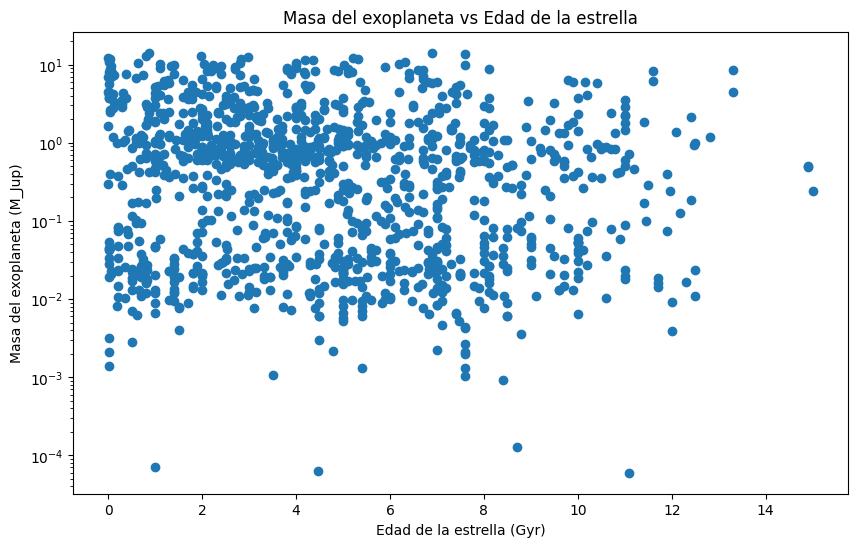

In [4]:

service = vo.dal.TAPService("http://voparis-tap-planeto.obspm.fr/tap")

# Obtenemos la edad de la estrella y la masa del exoplaneta
query = "SELECT granule_uid,star_age, mass FROM exoplanet.epn_core WHERE mass < 15 AND period>0 AND star_distance>0" 
results = service.search(query)
table = results.to_table()
df = table.to_pandas()
df.set_index('granule_uid',inplace = True)

# Nos aseguramos de eliminar las filas con datos faltantes en las columnas 'radius' y 'mass'
df = df.dropna(subset=['star_age', 'mass']) 
df.head()


#plot de masa vs edad
plt.figure(figsize=(10, 6))
plt.scatter(df['star_age'], df['mass'], alpha=1)
plt.yscale('log')
plt.xlabel('Edad de la estrella (Gyr)')
plt.ylabel('Masa del exoplaneta (M_Jup)')
plt.title('Masa del exoplaneta vs Edad de la estrella')
plt.show()
